# Code Division Multiple Access (CDMA) Lab

This notebook has four sections:

1. **Overview** -- we will introduce some concepts about CDMA, which is a very important technology used in wireless networks. 
2. **Interactive Playground** -- you can play around with different signals and codes and see what the receiver gets.
3. **Programming Assignment** -- you will implement a few lines of code to decode the coded signal at the receiver.
4. **Survey** -- did you learn something new and have fun while learning?
---

> If widgets don’t show up:
> - `pip install ipywidgets`
> - Classic Notebook: `jupyter nbextension enable --py widgetsnbextension`
---

## 1. Overview
---
In a wireless system, many users need to communicate over the same shared medium at the same time. Think about multiple people in an area using their phones to call others, browse the internet, and so on. The question is simple:

<div style="background-color: white; color: red; border: 2px solid black; padding: 10px; border-radius: 10px;width: fit-content;">
  <b>Q. How can multiple users transmit messages at the same time without interfering with each other?</b>
</div>

#### <u>CDMA:</u> 
Code Division Multiple Access (CDMA) allows multiple users to transmit messages at the same time and over the same frequency range by encoding their messages and then tranmsitting over the shared wireless medium. An intuitive way to understand this is to imagine a room where several conversations are happening simultaneously. If each speaker uses a different language, and a listener understands only one of those languages, then the listener can focus on the desired conversation while ignoring the rest. In CDMA, the “language” corresponds to the code.

#### <u>Chipping codes:</u> 
Each user is assigned a unique sequence of values, called a ```chipping code```. Instead of transmitting bits directly, the user encodes each bit using this sequence. The receiver, knowing the code of the intended sender, can extract that user’s signal even in the presence of many others.

#### <u>End-to-end Flow:</u>
To understand how CDMA works, lets start with a single sender-receiver pair.

**Single Sender-Receiver:** Suppose the sender wants to transmit a sequence of bits. In CDMA, each bit is first mapped to a numerical value (typically +1 for bit 1 and −1 for bit 0). The sender is assigned a chipping code, which is a sequence of +1 and −1 values.

To transmit a bit, the sender multiplies the bit value with every element of the chipping code to encode the bit. If the ith bit is $d_i$, and  $c_m$ is an m-th bit of an M-bit chipping code, then the encoded value $Z_{i, m}$ is:
$$Z_{i, m} = d_i . c_m$$
For example, if $d_i = -1$ and $c_m = [+1, -1, +1, -1]$, then $Z_{i, m} = [-1, +1, -1, +1]$.

At the receiver, the same chipping code is used to recover the bit, using the following equation:
$$d_i = \frac{\sum_{m=1}^{M} Z_{i, m} . c_m}{M}$$


**Multiple Senders-Receivers:** Now it gets really interesting! Now consider multiple users transmitting simultaneously over the same channel. Each user has a different chipping code and encodes their bits independently using their respective codes. In the wireless medium, signals from all users are added together. Therefore, the receiver observes a superposition (sum) of all transmitted chip sequences. Assuming $N$ senders, the encoded signal can be calculated as follows:

$$ Z^*_{i,m} = \sum_{s=1}^{N} d^S_i . c^S_m $$

To recover a particular user’s data, the receiver uses that user’s chipping code. It multiplies the combined signal with the desired code and sums the result. Due to the properties of the codes (discussed next), the contribution from other users averages out to zero, while the desired user’s signal is reinforced. This allows multiple users to transmit at the same time without explicit coordination in time or frequency. Thus, a receiver can decode a particular sender's bit by using the below formula:

$$ d^S_i = \frac{ \sum_{m=1}^{M} Z^*_{i, m} . c^S_m}{M} $$


A picture usually conveys a thousand words, and so, we illustrate the case of two senders and two receivers using CDMA using the following figure (source: [1]).

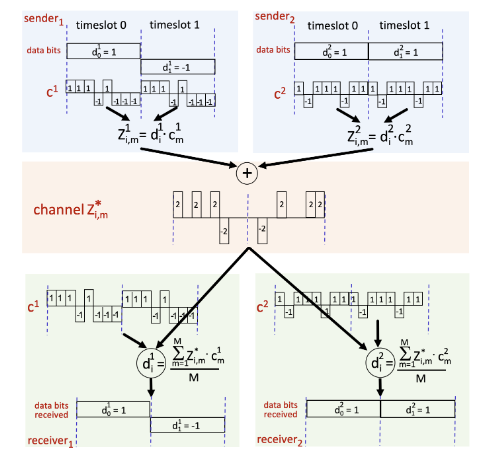
(Image source: [1])

The 8-bit code used by sender1 is $[1, 1, 1, -1, 1, -1, -1, -1]$, while the code being used by sender2 is $[1, -1, 1, 1, 1, -1, 1, 1]$. The bottom portion of this figure shows two receivers recovering the original data bits from the respective senders. We see that receiver1 is able correctly decode the data from sender 1 in spite of the interfering transmissions from sender2!

#### <u>Orthogonality of Chipping Codes:</u>
<div style="background-color: white; color: red; border: 2px solid black; padding: 10px; border-radius: 10px;width: fit-content;">
  <b>Q. If two users accidentally used the same chipping code, what would happen at the receiver?</b>
</div>

For CDMA to work effectively, the chipping codes assigned to different users must be orthogonal. Two codes are **orthogonal** if their dot product is zero. In simple terms, this means that when one code is compared with another, their contributions cancel out. This property is crucial during decoding. When the receiver multiplies the combined signal with a particular user’s code, the desired signal aligns with the code. Signals from other users, whose codes are orthogonal, produce values that cancel out when summed.

You can think of orthogonality geometrically, by thinking of vectors at right angles: one vector has no projection onto another, and therefore they do not interfere.

#### <u>CDMA in use today:</u>
CDMA has been widely used in real-world communication systems, particularly in earlier generations of cellular networks (3G). Today, CDMA is extensively used in satellite GPS communications, military and secure communications, and so on.

---
<div style="background-color: white; color: red; border: 2px solid black; padding: 10px; border-radius: 10px;width: fit-content;">
  <b>Interested to learn more?</b>
</div>

We are not covering more details about CDMA (e.g., how to generate chipping codes), but you can always search online for more information if you a interested! A good place to start may be this article by Prof. Jim Kurose [1], and this Wikipedia article [2].

---
### <u>References:</u>
[1] https://gaia.cs.umass.edu/wireless_and_mobile_networks/readings/Chapter_3_multiple_access_techniques.pdf

[2] https://en.wikipedia.org/wiki/Hadamard_code

---
<div style="background-color: white; color: red; border: 2px solid black; padding: 10px; border-radius: 10px;width: fit-content;">
  <b>Disclaimer: Some of the text above has been generated/polished using Gen AI. The text has been verified, but please let us know if you find any errors.</b>
</div>

---

## 2) Interactive Playground

Adjust the controls to see:
- received chip stream (sum + noise)
- correlation values and recovered bits

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hadamard

import ipywidgets as widgets
from IPython.display import display, clear_output


def rand_pm1(n):
    return np.where(np.random.rand(n) < 0.5, -1, 1)

def make_codes(U, L):
    H = hadamard(L)
    idx = np.random.choice(L, U, replace=False)
    return H[idx]

def cdma_once(U=3, L=16, noise=0, bits=None, codes=None):
    if codes is None:
        codes = make_codes(U, L)
    if bits is None:
        bits = rand_pm1(U)

    tx_users = codes * bits[:, None]     # (U,L)
    sum_sig = tx_users.sum(axis=0)       # (L,)
    rx = sum_sig + noise * np.random.randn(L)

    corrs = codes @ rx                   # (U,)
    rec_bits = np.where(corrs >= 0, 1, -1)
    return codes, bits, rx, corrs, rec_bits


num_users = widgets.Dropdown(options=[2, 3, 4], value=3, description="Users:")
chip_len = widgets.Dropdown(options=[8, 16, 32], value=16, description="Chip L:")
noise = widgets.FloatSlider(value=0, min=0, max=1.0, step=0.01, description="Noise:")
new_codes_btn = widgets.Button(description="New codes")
random_bits_btn = widgets.Button(description="Random bits")

bits_box = widgets.HBox([])
codes_out = widgets.Textarea(value="", description="Codes:", layout=widgets.Layout(width="100%", height="120px"))
recv_out = widgets.Textarea(value="", description="Recovered:", layout=widgets.Layout(width="100%", height="120px"))
plot_out = widgets.Output(layout=widgets.Layout(width="100%"))

state = {"codes": None, "bits": None}

def rebuild_bits_ui(U):
    ds = []
    for i in range(U):
        dd = widgets.Dropdown(options=[-1, 1], value=1, description=f"U{i+1}")
        dd.observe(lambda *_: refresh(), "value")
        ds.append(dd)
    bits_box.children = ds

def get_bits_from_ui():
    return np.array([c.value for c in bits_box.children], dtype=int)

def set_bits_to_ui(bits):
    for i, b in enumerate(bits):
        bits_box.children[i].value = int(b)

def refresh(*_):
    U = int(num_users.value)
    L = int(chip_len.value)
    sig = float(noise.value)

    if state["codes"] is None or state["codes"].shape != (U, L):
        state["codes"] = make_codes(U, L)

    if len(bits_box.children) != U:
        rebuild_bits_ui(U)

    if state["bits"] is None or state["bits"].shape != (U,):
        state["bits"] = rand_pm1(U)
        set_bits_to_ui(state["bits"])

    bits = get_bits_from_ui()
    state["bits"] = bits

    codes, bits, rx, corrs, rec_bits = cdma_once(U=U, L=L, noise=sig, bits=bits, codes=state["codes"])

    codes_out.value = "\n".join([f"U{i+1}: [{ ' '.join(map(str, codes[i].tolist())) }]" for i in range(U)])
    recv_out.value = "\n".join([f"U{i+1}: corr={corrs[i]:.2f}  -> bit={rec_bits[i]}" for i in range(U)])

    with plot_out:
        clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(10, 2.5))
        ax.set_title("Received chips (sum + noise)")
        ax.axhline(0, lw=1)
        ax.bar(range(L), rx)
        bars = ax.bar(range(L), rx)
        ax.bar_label(bars, fmt="%.1f", label_type="center", fontsize=8, color="white", fontweight="bold")
        ax.set_xlabel("chip index")
        ax.set_ylabel("value")
        plt.show()

        fig, ax = plt.subplots(figsize=(10, 2.5))
        ax.set_title("Correlation values (per user)")
        ax.axhline(0, lw=1)
        ax.bar([f"U{i+1}" for i in range(U)], corrs)
        ax.set_ylabel("corr")
        plt.show()

def new_codes(_):
    U = int(num_users.value)
    L = int(chip_len.value)
    state["codes"] = make_codes(U, L)
    refresh()

def random_bits(_):
    U = int(num_users.value)
    state["bits"] = rand_pm1(U)
    set_bits_to_ui(state["bits"])
    refresh()

num_users.observe(refresh, "value")
chip_len.observe(refresh, "value")
noise.observe(refresh, "value")
new_codes_btn.on_click(new_codes)
random_bits_btn.on_click(random_bits)

ui = widgets.VBox([
    widgets.HBox([num_users, chip_len, noise, new_codes_btn, random_bits_btn]),
    widgets.HTML("<b>User bits</b> (set each to -1 or +1):"),
    bits_box,
    widgets.HBox([codes_out, recv_out]),
    plot_out
])

display(ui)
refresh()

## 3) Programming Assignment (Python or C++)

- Both templates separate the CDMA pipeline into four functions:
  1. Encoding
  2. Modulation
  3. Demodulation
  4. Decoding
- Each stage has clear TODO blocks so you can hide/reveal parts during instruction.
- Instructor-only verification uses a shared reference library from the `ref/` folder.

> Build the reference library first (instructor setup):
> - Windows: `powershell -ExecutionPolicy Bypass -File .\instructor_ref\build_ref_lib.ps1`
> - Linux/macOS: `bash ./instructor_ref/build_ref_lib.sh`

- **Python** runs directly in this kernel.
- **C++** compiles the student template plus a hidden test harness and runs it.

In [ ]:
import os
import re
import sys
import ctypes
import tempfile
import subprocess
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# A small orthogonal code set used in public + hidden checks.
TEST_CODES = np.array([
    [1, 1, 1, 1, 1, 1, 1, 1],
    [1, -1, 1, -1, 1, -1, 1, -1],
    [1, 1, -1, -1, 1, 1, -1, -1],
], dtype=np.int32)

PUBLIC_BITS = np.array([1, -1, 1], dtype=np.int32)


def _build_hint():
    if sys.platform.startswith("win"):
        return "powershell -ExecutionPolicy Bypass -File .\\instructor_ref\\build_ref_lib.ps1"
    return "bash ./instructor_ref/build_ref_lib.sh"


def _run_build_command():
    if sys.platform.startswith("win"):
        script = os.path.join(os.getcwd(), "instructor_ref", "build_ref_lib.ps1")
        if not os.path.exists(script):
            raise FileNotFoundError(f"Build script not found: {script}")
        return subprocess.run(
            ["powershell", "-ExecutionPolicy", "Bypass", "-File", script],
            capture_output=True,
            text=True,
        )

    script = os.path.join(os.getcwd(), "instructor_ref", "build_ref_lib.sh")
    if not os.path.exists(script):
        raise FileNotFoundError(f"Build script not found: {script}")
    return subprocess.run(["bash", script], capture_output=True, text=True)


def _ref_lib_path():
    base = os.path.join(os.getcwd(), "ref")
    if sys.platform.startswith("win"):
        return os.path.join(base, "cdma_ref.dll")
    if sys.platform == "darwin":
        return os.path.join(base, "libcdma_ref.dylib")
    return os.path.join(base, "libcdma_ref.so")


_ref_fn = None


def _load_ref_fn():
    global _ref_fn
    if _ref_fn is not None:
        return _ref_fn

    lib_path = _ref_lib_path()
    if not os.path.exists(lib_path):
        return None

    lib = ctypes.CDLL(lib_path)
    fn = lib.cdma_reference_decode
    fn.argtypes = [
        ctypes.c_int,
        ctypes.c_int,
        ctypes.POINTER(ctypes.c_int),
        ctypes.POINTER(ctypes.c_int),
        ctypes.c_double,
        ctypes.c_uint,
        ctypes.POINTER(ctypes.c_int),
    ]
    fn.restype = ctypes.c_int
    _ref_fn = fn
    return fn


def reference_decode(bits, codes, noise_std=0.0, seed=7):
    fn = _load_ref_fn()
    if fn is None:
        raise FileNotFoundError(
            "Reference library not found. Build it with: "
            f"{_build_hint()}"
        )

    bits = np.asarray(bits, dtype=np.int32)
    codes = np.asarray(codes, dtype=np.int32)
    users, chip_len = codes.shape

    if bits.shape != (users,):
        raise ValueError(f"bits shape {bits.shape} does not match users={users}")

    flat_codes = np.ascontiguousarray(codes.reshape(-1), dtype=np.int32)
    out = np.zeros(users, dtype=np.int32)

    rc = fn(
        int(users),
        int(chip_len),
        bits.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
        flat_codes.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
        float(noise_std),
        int(seed),
        out.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
    )
    if rc != 0:
        raise RuntimeError(f"Reference library returned error code: {rc}")
    return out


py_template = '''import numpy as np

# ============================================================
# CDMA Student Template (Python)
# Pipeline: encode -> modulate -> demodulate -> decode
# ============================================================

def encode(bits, codes):
    """Encode each user bit with that user's chipping code.
    bits:  shape (U,), values in {-1, +1}
    codes: shape (U, L), values in {-1, +1}
    returns encoded chips with shape (U, L)
    """
    # TODO: implement encoding
    return bits[:, None] * codes


def modulate(encoded_chips):
    """Combine all users on the shared channel.
    encoded_chips: shape (U, L)
    returns tx_signal: shape (L,)
    """
    # TODO: implement modulation (sum across users)
    return encoded_chips.sum(axis=0)


def demodulate(tx_signal, noise_std=0.0, rng=None):
    """Channel / receiver front-end.
    Add optional Gaussian noise and return received chips.
    """
    # TODO: implement demodulation/channel handling
    if rng is None:
        rng = np.random.default_rng(0)
    return tx_signal + noise_std * rng.normal(size=tx_signal.shape[0])


def decode(rx_signal, codes):
    """Recover each user bit by correlation with each user's code.
    rx_signal: shape (L,)
    codes:     shape (U, L)
    returns bits_hat: shape (U,), values in {-1, +1}
    """
    # TODO: implement decoding
    corr = codes @ rx_signal
    return np.where(corr >= 0, 1, -1)


def run_cdma_pipeline(bits, codes, noise_std=0.0, seed=7):
    """Keep this wrapper for testing; students usually edit stage functions above."""
    bits = np.asarray(bits, dtype=np.int32)
    codes = np.asarray(codes, dtype=np.int32)
    encoded = encode(bits, codes)
    tx_signal = modulate(encoded)
    rng = np.random.default_rng(seed)
    rx_signal = demodulate(tx_signal, noise_std=noise_std, rng=rng)
    bits_hat = decode(rx_signal, codes)
    return np.asarray(bits_hat, dtype=np.int32)
'''

cpp_template = r'''#include <vector>
#include <numeric>

// ============================================================
// CDMA Student Template (C++)
// Pipeline: encode -> modulate -> demodulate -> decode
// ============================================================

std::vector<std::vector<int>> encode(
    const std::vector<int>& bits,
    const std::vector<std::vector<int>>& codes
) {
    // TODO: implement encoding
    const int U = static_cast<int>(bits.size());
    const int L = static_cast<int>(codes[0].size());
    std::vector<std::vector<int>> out(U, std::vector<int>(L, 0));
    for (int u = 0; u < U; ++u) {
        for (int m = 0; m < L; ++m) {
            out[u][m] = bits[u] * codes[u][m];
        }
    }
    return out;
}

std::vector<double> modulate(const std::vector<std::vector<int>>& encoded_chips) {
    // TODO: implement modulation (sum across users)
    const int U = static_cast<int>(encoded_chips.size());
    const int L = static_cast<int>(encoded_chips[0].size());
    std::vector<double> tx(L, 0.0);
    for (int m = 0; m < L; ++m) {
        double s = 0.0;
        for (int u = 0; u < U; ++u) {
            s += static_cast<double>(encoded_chips[u][m]);
        }
        tx[m] = s;
    }
    return tx;
}

std::vector<double> demodulate(
    const std::vector<double>& tx_signal,
    double noise_std,
    unsigned int seed
) {
    // TODO: implement demodulation/channel handling
    // Reference checks use noise_std=0, so pass-through is acceptable initially.
    (void)noise_std;
    (void)seed;
    return tx_signal;
}

std::vector<int> decode(
    const std::vector<double>& rx_signal,
    const std::vector<std::vector<int>>& codes
) {
    // TODO: implement decoding
    const int U = static_cast<int>(codes.size());
    const int L = static_cast<int>(codes[0].size());
    std::vector<int> bits_hat(U, -1);
    for (int u = 0; u < U; ++u) {
        double corr = 0.0;
        for (int m = 0; m < L; ++m) {
            corr += rx_signal[m] * static_cast<double>(codes[u][m]);
        }
        bits_hat[u] = (corr >= 0.0) ? 1 : -1;
    }
    return bits_hat;
}
'''


HARNESS_CPP = r'''
#include <iostream>
#include <vector>

std::vector<std::vector<int>> encode(
    const std::vector<int>& bits,
    const std::vector<std::vector<int>>& codes
);
std::vector<double> modulate(const std::vector<std::vector<int>>& encoded_chips);
std::vector<double> demodulate(
    const std::vector<double>& tx_signal,
    double noise_std,
    unsigned int seed
);
std::vector<int> decode(
    const std::vector<double>& rx_signal,
    const std::vector<std::vector<int>>& codes
);

int main() {
    std::vector<int> bits = {1, -1, 1};
    std::vector<std::vector<int>> codes = {
        {1, 1, 1, 1, 1, 1, 1, 1},
        {1, -1, 1, -1, 1, -1, 1, -1},
        {1, 1, -1, -1, 1, 1, -1, -1}
    };

    auto encoded = encode(bits, codes);
    auto tx = modulate(encoded);
    auto rx = demodulate(tx, 0.0, 7);
    auto out = decode(rx, codes);

    for (size_t i = 0; i < out.size(); ++i) {
        if (i) std::cout << ' ';
        std::cout << (out[i] >= 0 ? 1 : -1);
    }
    std::cout << std::endl;
    return 0;
}
'''

py_editor = widgets.Textarea(value=py_template, layout=widgets.Layout(width="100%", height="360px"))
cpp_editor = widgets.Textarea(value=cpp_template, layout=widgets.Layout(width="100%", height="360px"))

out = widgets.Output(layout=widgets.Layout(width="100%"))
run_py_btn = widgets.Button(description="Run Python Template ▶")
run_cpp_btn = widgets.Button(description="Run C++ Template ▶")
reset_py_btn = widgets.Button(description="Reset")
reset_cpp_btn = widgets.Button(description="Reset")
build_ref_btn = widgets.Button(description="Build Ref Library (Instructor)")


def _print_vec(name, v):
    print(f"{name}: [{', '.join(str(int(x)) for x in v)}]")


def _normalize_sign(arr):
    arr = np.asarray(arr)
    return np.where(arr >= 0, 1, -1).astype(np.int32)


def run_python(_):
    with out:
        clear_output()
        namespace = {}

        try:
            exec(py_editor.value, namespace)
        except Exception as e:
            print("Python syntax/runtime error while loading template:")
            print(e)
            return

        required = ["encode", "modulate", "demodulate", "decode", "run_cdma_pipeline"]
        missing = [name for name in required if name not in namespace]
        if missing:
            print("Missing required functions:", ", ".join(missing))
            return

        try:
            pred = namespace["run_cdma_pipeline"](PUBLIC_BITS.copy(), TEST_CODES.copy(), noise_std=0.0, seed=7)
            pred = _normalize_sign(pred)
        except Exception as e:
            print("Error while running run_cdma_pipeline:")
            print(e)
            return

        _print_vec("Student output", pred)

        try:
            ref = reference_decode(PUBLIC_BITS, TEST_CODES, noise_std=0.0, seed=7)
            _print_vec("Reference output", ref)
            print("Public check:", "PASS" if np.array_equal(pred, ref) else "FAIL")
        except Exception as e:
            print("Reference check unavailable:")
            print(e)
            print(f"Tip: build the shared library with: {_build_hint()}")
            return

        # Hidden-style randomized checks against reference implementation.
        rng = np.random.default_rng(12345)
        for t in range(1, 6):
            bits_t = rng.choice([-1, 1], size=3).astype(np.int32)
            try:
                pred_t = namespace["run_cdma_pipeline"](bits_t.copy(), TEST_CODES.copy(), noise_std=0.0, seed=t)
                pred_t = _normalize_sign(pred_t)
                ref_t = reference_decode(bits_t, TEST_CODES, noise_std=0.0, seed=t)
            except Exception as e:
                print(f"Hidden check {t}: ERROR ({e})")
                return

            if not np.array_equal(pred_t, ref_t):
                print(f"Hidden check {t}: FAIL")
                _print_vec("  bits", bits_t)
                _print_vec("  student", pred_t)
                _print_vec("  reference", ref_t)
                return

        print("Hidden checks: PASS (5/5)")


def run_cpp(_):
    with out:
        clear_output()

        try:
            ref = reference_decode(PUBLIC_BITS, TEST_CODES, noise_std=0.0, seed=7)
        except Exception as e:
            print("Reference check unavailable:")
            print(e)
            print(f"Tip: build the shared library with: {_build_hint()}")
            return

        with tempfile.TemporaryDirectory() as d:
            user_cpp = os.path.join(d, "student.cpp")
            harness_cpp = os.path.join(d, "harness.cpp")
            exe = os.path.join(d, "student_runner.exe" if sys.platform.startswith("win") else "student_runner")

            with open(user_cpp, "w", encoding="utf-8") as f:
                f.write(cpp_editor.value)
            with open(harness_cpp, "w", encoding="utf-8") as f:
                f.write(HARNESS_CPP)

            try:
                comp = subprocess.run(
                    ["g++", "-std=c++17", "-O2", user_cpp, harness_cpp, "-o", exe],
                    capture_output=True,
                    text=True,
                )
            except FileNotFoundError:
                print("g++ not found. Install a C++ compiler (e.g., g++), then try again.")
                return

            if comp.stdout.strip():
                print("--- compile stdout ---")
                print(comp.stdout)
            if comp.stderr.strip():
                print("--- compile stderr ---")
                print(comp.stderr)

            if comp.returncode != 0:
                print("Compilation failed.")
                return

            run = subprocess.run([exe], capture_output=True, text=True)
            if run.returncode != 0:
                print("Program exited with code", run.returncode)
            if run.stdout.strip():
                print("--- program stdout ---")
                print(run.stdout.strip())
            if run.stderr.strip():
                print("--- program stderr ---")
                print(run.stderr.strip())

            vals = re.findall(r"-?\d+", run.stdout)
            if len(vals) < 3:
                print("Could not parse 3 decoded bits from program output.")
                return

            pred = _normalize_sign(np.array([int(vals[0]), int(vals[1]), int(vals[2])], dtype=np.int32))
            _print_vec("Parsed student output", pred)
            _print_vec("Reference output", ref)
            print("Public check:", "PASS" if np.array_equal(pred, ref) else "FAIL")


def build_ref(_):
    with out:
        clear_output()

        try:
            proc = _run_build_command()
        except Exception as e:
            print("Failed to start build:")
            print(e)
            return

        if proc.stdout.strip():
            print(proc.stdout.strip())
        if proc.stderr.strip():
            print(proc.stderr.strip())
        print("Build status:", "SUCCESS" if proc.returncode == 0 else f"FAILED ({proc.returncode})")


def reset_py(_):
    py_editor.value = py_template


def reset_cpp(_):
    cpp_editor.value = cpp_template


run_py_btn.on_click(run_python)
run_cpp_btn.on_click(run_cpp)
build_ref_btn.on_click(build_ref)
reset_py_btn.on_click(reset_py)
reset_cpp_btn.on_click(reset_cpp)

tabs = widgets.Tab(children=[
    widgets.VBox([widgets.HBox([reset_cpp_btn, run_cpp_btn]), cpp_editor]),
    widgets.VBox([widgets.HBox([reset_py_btn, run_py_btn]), py_editor]),
])
tabs.set_title(0, "C++")
tabs.set_title(1, "Python")

display(widgets.VBox([build_ref_btn, tabs]), out)

Output(layout=Layout(width='100%'))

## 4) Survey

**This would be an anonymous Google form.**

1. How familiar were you with CDMA concepts before starting this assignment?  
(Scale: Not familiar → Very familiar)

2. How comfortable do you feel with CDMA concepts after completing the assignment?  
(Scale: Not familiar → Very familiar)

3. Do you feel confident explaining CDMA to others after completing this assignment?  
(Scale: Not confident → Very confident)

4. What is one thing about this lab that you liked the most?  
(Open‑ended)

5. What is one thing you would suggest to improve in this lab?  
(Open‑ended)
